# 11.5 RNN 与 GAN 基础

> **模块十一 · PyTorch深度学习实践** | 第9-10课时
>
> **学习目标：**
> 1. 理解 RNN 的基本结构和梯度问题
> 2. 掌握 LSTM 和 GRU 的门控机制
> 3. 使用 PyTorch 构建序列预测模型
> 4. 理解 GAN 的对抗训练原理
> 5. 了解常见 GAN 变体

---

# 第一部分：循环神经网络 (RNN)

---
## 1. 为什么需要 RNN？

传统前馈网络（MLP、CNN）处理的是**固定大小的输入**，且每次输入之间**相互独立**。

但很多数据具有**序列特性**：
- 自然语言："我**喜欢**深度学习" → 上下文决定语义
- 时间序列：股票价格、气温变化
- 音频信号：声波随时间变化

RNN 通过**隐藏状态 (Hidden State)** 记忆历史信息，处理变长序列数据。

## 2. RNN 基本结构

### 2.1 前向传播

RNN 在每个时间步 $t$ 的计算：

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$
$$y_t = W_{hy} h_t + b_y$$

其中：
- $x_t \in \mathbb{R}^{d}$：时间步 $t$ 的输入
- $h_t \in \mathbb{R}^{h}$：时间步 $t$ 的隐藏状态
- $y_t \in \mathbb{R}^{o}$：时间步 $t$ 的输出
- $W_{hh} \in \mathbb{R}^{h \times h}$：隐藏到隐藏的权重
- $W_{xh} \in \mathbb{R}^{h \times d}$：输入到隐藏的权重

**关键特点：**
- 同一组参数在每个时间步**共享**
- 隐藏状态 $h_t$ 携带历史信息，是 RNN 的"记忆"

### 2.2 时间展开

```
x_0 → [RNN] → h_0 → y_0
         ↑
x_1 → [RNN] → h_1 → y_1
         ↑
x_2 → [RNN] → h_2 → y_2
```

信息从左到右流动，每个时间步的 $h_{t-1}$ 作为下一时间步的输入。

### 2.3 梯度消失与梯度爆炸

RNN 在反向传播中，梯度需要经过**多步链式法则**：

$$\frac{\partial L}{\partial h_0} = \frac{\partial L}{\partial h_T} \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

其中：

$$\frac{\partial h_t}{\partial h_{t-1}} = \text{diag}(\tanh'(\cdot)) \cdot W_{hh}$$

- 当 $\|\frac{\partial h_t}{\partial h_{t-1}}\| < 1$ 时，梯度**指数衰减** → **梯度消失**
- 当 $\|\frac{\partial h_t}{\partial h_{t-1}}\| > 1$ 时，梯度**指数增长** → **梯度爆炸**

**解决方案：**
- 梯度裁剪 (Gradient Clipping)
- LSTM / GRU（通过门控机制缓解梯度消失）

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
# 设置matplotlib显示中文字体，防止中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei'] # 任选一个可用的中文字体
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

print(f"PyTorch 版本: {torch.__version__}")

PyTorch 版本: 2.6.0+cpu


In [11]:
# ========== PyTorch RNN 基本使用 ==========

# 参数说明:
# input_size:   输入特征维度 d
# hidden_size:  隐藏状态维度 h
# num_layers:   RNN 层数 (堆叠层数)
# batch_first:  输入形状是否为 (batch, seq, features) = True

rnn = nn.RNN(
    input_size=10,    # 每个时间步输入10维
    hidden_size=32,   # 隐藏状态32维
    num_layers=2,     # 2层RNN
    batch_first=True  # 输入 (batch, seq, features)
)

# 输入: (batch_size, seq_len, input_size)
batch_size = 4
seq_len = 5
x = torch.randn(batch_size, seq_len, 10)

# 初始隐藏状态: (num_layers, batch_size, hidden_size)
h0 = torch.zeros(2, batch_size, 32)

# 前向传播
output, hn = rnn(x, h0)

print(f"输入形状:    {x.shape}")       # (4, 5, 10)
print(f"输出形状:    {output.shape}")    # (4, 5, 32) - 每个时间步的隐藏状态
print(f"最终隐藏状态: {hn.shape}")       # (2, 4, 32) - 每层最后一个时间步的状态

# 验证: output 的最后一个时间步 = hn 的第0层
print(f"\noutput[:, -1, :] == hn[0] ? {torch.allclose(output[:, -1, :], hn[0])}")

输入形状:    torch.Size([4, 5, 10])
输出形状:    torch.Size([4, 5, 32])
最终隐藏状态: torch.Size([2, 4, 32])

output[:, -1, :] == hn[0] ? False


In [12]:
# ========== 只取最后一个时间步的输出 (分类任务常用) ==========
last_output = output[:, -1, :]  # (batch, hidden)
print(f"最后时间步输出: {last_output.shape}")

# 接全连接层做分类
classifier = nn.Linear(32, 5)  # 5分类
logits = classifier(last_output)
print(f"分类输出: {logits.shape}")  # (4, 5)

最后时间步输出: torch.Size([4, 32])
分类输出: torch.Size([4, 5])


---
## 3. LSTM (Long Short-Term Memory)

LSTM 通过引入**门控机制**有效解决了 RNN 的梯度消失问题。

### 3.1 三个门

LSTM 在标准 RNN 的基础上引入了三个门：

**1. 遗忘门 (Forget Gate) $f_t$** — 决定丢弃哪些旧信息

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

**2. 输入门 (Input Gate) $i_t$** — 决定存储哪些新信息

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$

$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

**3. 输出门 (Output Gate) $o_t$** — 决定输出哪些信息

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

### 3.2 细胞状态更新

**细胞状态 (Cell State) $C_t$** — LSTM 的"长期记忆"

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**隐藏状态 (Hidden State) $h_t$** — LSTM 的"短期记忆"

$$h_t = o_t \odot \tanh(C_t)$$

其中 $\odot$ 表示逐元素乘法（Hadamard积），$\sigma$ 为 sigmoid 函数。

**直觉理解：**
- $C_t$ 像一条"传送带"，信息可以在上面流畅地传递（加法而非乘法），缓解梯度消失
- 三个门像"阀门"，控制信息的流入、保留和流出

In [13]:
# ========== PyTorch LSTM 使用 ==========

lstm = nn.LSTM(
    input_size=10,     # 输入特征维度
    hidden_size=32,    # 隐藏状态维度
    num_layers=2,      # LSTM 层数
    batch_first=True,  # (batch, seq, features)
    bidirectional=False,  # 单向
    dropout=0.2        # 层间 dropout
)

# 输入
x = torch.randn(4, 5, 10)  # (batch=4, seq=5, features=10)

# 初始状态: h_0 和 c_0
h0 = torch.zeros(2, 4, 32)  # (num_layers, batch, hidden)
c0 = torch.zeros(2, 4, 32)  # (num_layers, batch, hidden)

# 前向传播
output, (hn, cn) = lstm(x, (h0, c0))

print(f"输入:       {x.shape}")         # (4, 5, 10)
print(f"输出:       {output.shape}")     # (4, 5, 32)
print(f"最终隐藏状态: {hn.shape}")        # (2, 4, 32)
print(f"最终细胞状态: {cn.shape}")        # (2, 4, 32)

输入:       torch.Size([4, 5, 10])
输出:       torch.Size([4, 5, 32])
最终隐藏状态: torch.Size([2, 4, 32])
最终细胞状态: torch.Size([2, 4, 32])


In [14]:
# ========== 双向 LSTM ==========

bilstm = nn.LSTM(
    input_size=10,
    hidden_size=32,
    num_layers=1,
    batch_first=True,
    bidirectional=True  # 双向!
)

x = torch.randn(4, 5, 10)
output, (hn, cn) = bilstm(x)

print(f"双向 LSTM:")
print(f"  输入:   {x.shape}")
print(f"  输出:   {output.shape}")   # (4, 5, 64) 隐藏维度 x2
print(f"  hn:     {hn.shape}")        # (2, 4, 32) 层数 x2 (正向+反向)
print(f"  cn:     {cn.shape}")

# 双向 LSTM 参数翻倍
print(f"\n单向LSTM参数量: {sum(p.numel() for p in lstm.parameters()):,}")
print(f"双向LSTM参数量: {sum(p.numel() for p in bilstm.parameters()):,}")

双向 LSTM:
  输入:   torch.Size([4, 5, 10])
  输出:   torch.Size([4, 5, 64])
  hn:     torch.Size([2, 4, 32])
  cn:     torch.Size([2, 4, 32])

单向LSTM参数量: 14,080
双向LSTM参数量: 11,264


### 3.3 LSTM 为什么能解决梯度消失？

关键在于细胞状态的更新公式：

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

梯度沿 $C_t$ 传播时：

$$\frac{\partial C_t}{\partial C_{t-1}} = f_t$$

- 当 $f_t \approx 1$ 时，梯度可以**几乎无损地传递**到很远的过去
- 遗忘门可以**学习**在需要时打开/关闭，自适应地控制记忆长度

相比之下，普通 RNN 的梯度涉及 $\tanh'$ 和矩阵乘法，容易衰减。

---
## 4. GRU (Gated Recurrent Unit)

GRU 是 LSTM 的简化版，将遗忘门和输入门合并为一个**更新门**。

### 4.1 两个门

**重置门 (Reset Gate) $r_t$：**

$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$

**更新门 (Update Gate) $z_t$：**

$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$

### 4.2 状态更新

$$n_t = \tanh(W_n \cdot [r_t \odot h_{t-1}, x_t])$$

$$h_t = (1 - z_t) \odot n_t + z_t \odot h_{t-1}$$

### 4.3 LSTM vs GRU

| 特性 | LSTM | GRU |
|------|------|-----|
| 门数量 | 3 (遗忘、输入、输出) | 2 (重置、更新) |
| 隐藏状态 | $h_t, C_t$ | 只有 $h_t$ |
| 参数量 | 4 × (hidden × (input + hidden + 1)) | 3 × (hidden × (input + hidden + 1)) |
| 训练速度 | 较慢 | 较快 |
| 长序列能力 | 略强 | 略弱 |
| 适用场景 | 长序列、复杂任务 | 较短序列、效率优先 |

In [15]:
# ========== PyTorch GRU 使用 ==========

gru = nn.GRU(
    input_size=10,
    hidden_size=32,
    num_layers=2,
    batch_first=True,
    dropout=0.2
)

x = torch.randn(4, 5, 10)
h0 = torch.zeros(2, 4, 32)

output, hn = gru(x, h0)

print(f"GRU:")
print(f"  输入: {x.shape} → 输出: {output.shape}")
print(f"  最终隐藏状态: {hn.shape}")

# 参数量对比
print(f"\n参数量对比:")
print(f"  RNN:  {sum(p.numel() for p in nn.RNN(10, 32, 2).parameters()):,}")
print(f"  GRU:  {sum(p.numel() for p in nn.GRU(10, 32, 2).parameters()):,}")
print(f"  LSTM: {sum(p.numel() for p in nn.LSTM(10, 32, 2).parameters()):,}")

GRU:
  输入: torch.Size([4, 5, 10]) → 输出: torch.Size([4, 5, 32])
  最终隐藏状态: torch.Size([2, 4, 32])

参数量对比:
  RNN:  3,520
  GRU:  10,560
  LSTM: 14,080


---
## 5. 实战：用 RNN/LSTM 进行正弦波预测

使用历史序列预测下一个值（序列预测任务）。

X 形状: torch.Size([1000, 20, 1])
y 形状: torch.Size([1000])


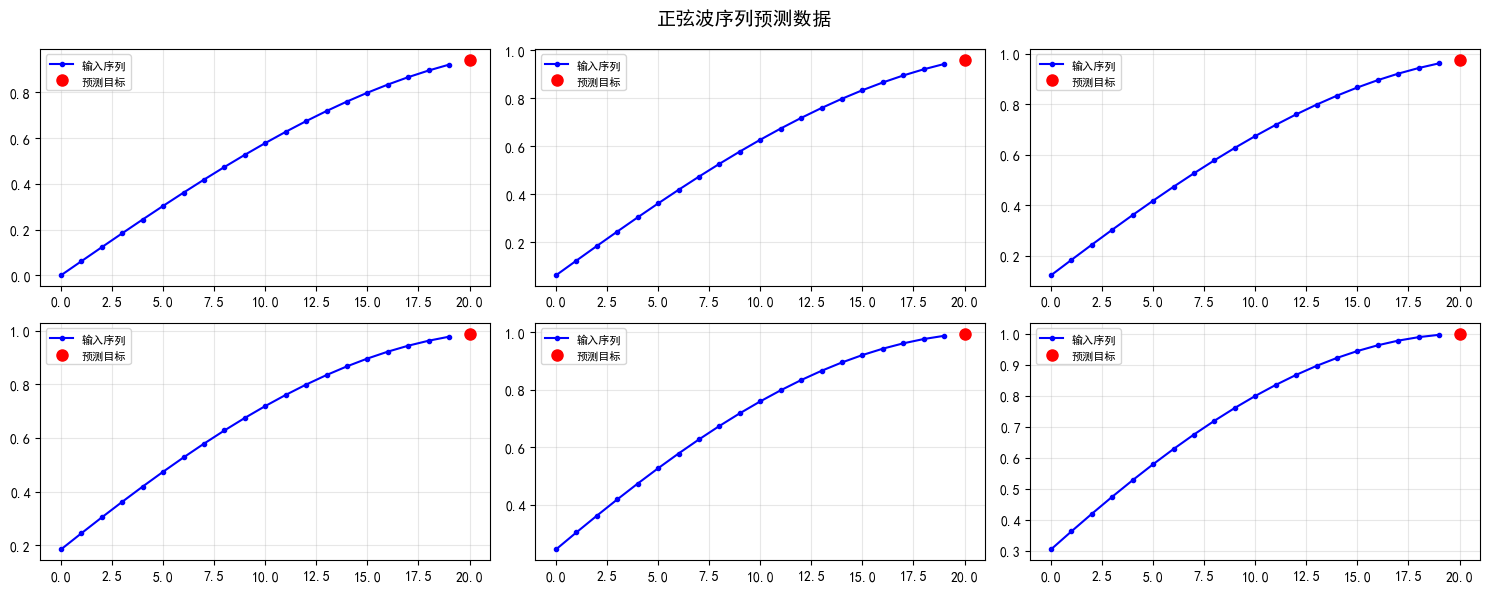

In [16]:
# ========== 1. 生成正弦波数据 ==========

def create_sine_data(seq_len=20, n_samples=1000):
    """生成正弦波序列数据"""
    X, y = [], []
    t = np.linspace(0, 20 * np.pi, n_samples + seq_len)
    data = np.sin(t)
    
    for i in range(n_samples):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    
    X = torch.FloatTensor(X).unsqueeze(-1)  # (N, seq_len, 1)
    y = torch.FloatTensor(y)                   # (N,)
    return X, y


seq_len = 20
X, y = create_sine_data(seq_len=seq_len, n_samples=1000)

print(f"X 形状: {X.shape}")  # (1000, 20, 1)
print(f"y 形状: {y.shape}")  # (1000,)

# 可视化几个样本
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for idx, ax in enumerate(axes.flat):
    ax.plot(range(seq_len), X[idx].numpy().flatten(), 'b-o', markersize=3, label='输入序列')
    ax.plot(seq_len, y[idx].numpy(), 'ro', markersize=8, label='预测目标')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('正弦波序列预测数据', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# ========== 2. 定义模型 ==========

class SequencePredictor(nn.Module):
    """使用 RNN/LSTM/GRU 进行序列预测"""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, model_type='lstm'):
        super().__init__()
        self.model_type = model_type
        self.hidden_size = hidden_size
        
        if model_type == 'rnn':
            self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        elif model_type == 'lstm':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        elif model_type == 'gru':
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        if self.model_type == 'lstm':
            out, (hn, cn) = self.rnn(x)
        else:
            out, hn = self.rnn(x)
        
        # 取最后一个时间步的隐藏状态
        last_hidden = out[:, -1, :]  # (batch, hidden)
        prediction = self.fc(last_hidden)  # (batch, 1)
        return prediction.squeeze(-1)  # (batch,)


# 创建不同类型的模型
models = {
    'RNN':  SequencePredictor(model_type='rnn'),
    'LSTM': SequencePredictor(model_type='lstm'),
    'GRU':  SequencePredictor(model_type='gru'),
}

for name, model in models.items():
    params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {params:,} 参数")

RNN: 12,673 参数
LSTM: 50,497 参数
GRU: 37,889 参数


In [18]:
# ========== 3. 训练 ==========

def train_model(model, X, y, n_epochs=200, lr=0.001, verbose=True):
    """训练序列预测模型"""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # 划分训练/测试集
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    train_losses = []
    test_losses = []
    
    for epoch in range(n_epochs):
        model.train()
        output = model(X_train)
        loss = criterion(output, y_train)
        
        optimizer.zero_grad()
        loss.backward()
        
        # 梯度裁剪 (RNN 训练的重要技巧)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_losses.append(loss.item())
        
        # 评估
        if (epoch + 1) % 20 == 0 or epoch == 0:
            model.eval()
            with torch.no_grad():
                test_output = model(X_test)
                test_loss = criterion(test_output, y_test)
                test_losses.append(test_loss.item())
                if verbose:
                    print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                          f"Train Loss: {loss.item():.6f} | Test Loss: {test_loss.item():.6f}")
    
    return train_losses, X_test, y_test, model


# 训练所有模型
results = {}
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"训练 {name} 模型")
    print('='*40)
    train_loss, X_test, y_test, trained_model = train_model(model, X, y, n_epochs=200)
    results[name] = {
        'train_loss': train_loss,
        'X_test': X_test,
        'y_test': y_test,
        'model': trained_model
    }


训练 RNN 模型
Epoch   1/200 | Train Loss: 0.541286 | Test Loss: 0.482588
Epoch  20/200 | Train Loss: 0.029946 | Test Loss: 0.029921
Epoch  40/200 | Train Loss: 0.001423 | Test Loss: 0.001637
Epoch  60/200 | Train Loss: 0.000323 | Test Loss: 0.000477
Epoch  80/200 | Train Loss: 0.000221 | Test Loss: 0.000210
Epoch 100/200 | Train Loss: 0.000141 | Test Loss: 0.000141
Epoch 120/200 | Train Loss: 0.000129 | Test Loss: 0.000128
Epoch 140/200 | Train Loss: 0.000118 | Test Loss: 0.000117
Epoch 160/200 | Train Loss: 0.000108 | Test Loss: 0.000107
Epoch 180/200 | Train Loss: 0.000099 | Test Loss: 0.000098
Epoch 200/200 | Train Loss: 0.000090 | Test Loss: 0.000089

训练 LSTM 模型
Epoch   1/200 | Train Loss: 0.501300 | Test Loss: 0.500617
Epoch  20/200 | Train Loss: 0.108080 | Test Loss: 0.104466
Epoch  40/200 | Train Loss: 0.057899 | Test Loss: 0.055718
Epoch  60/200 | Train Loss: 0.023068 | Test Loss: 0.021182
Epoch  80/200 | Train Loss: 0.001730 | Test Loss: 0.002020
Epoch 100/200 | Train Loss: 0.000

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

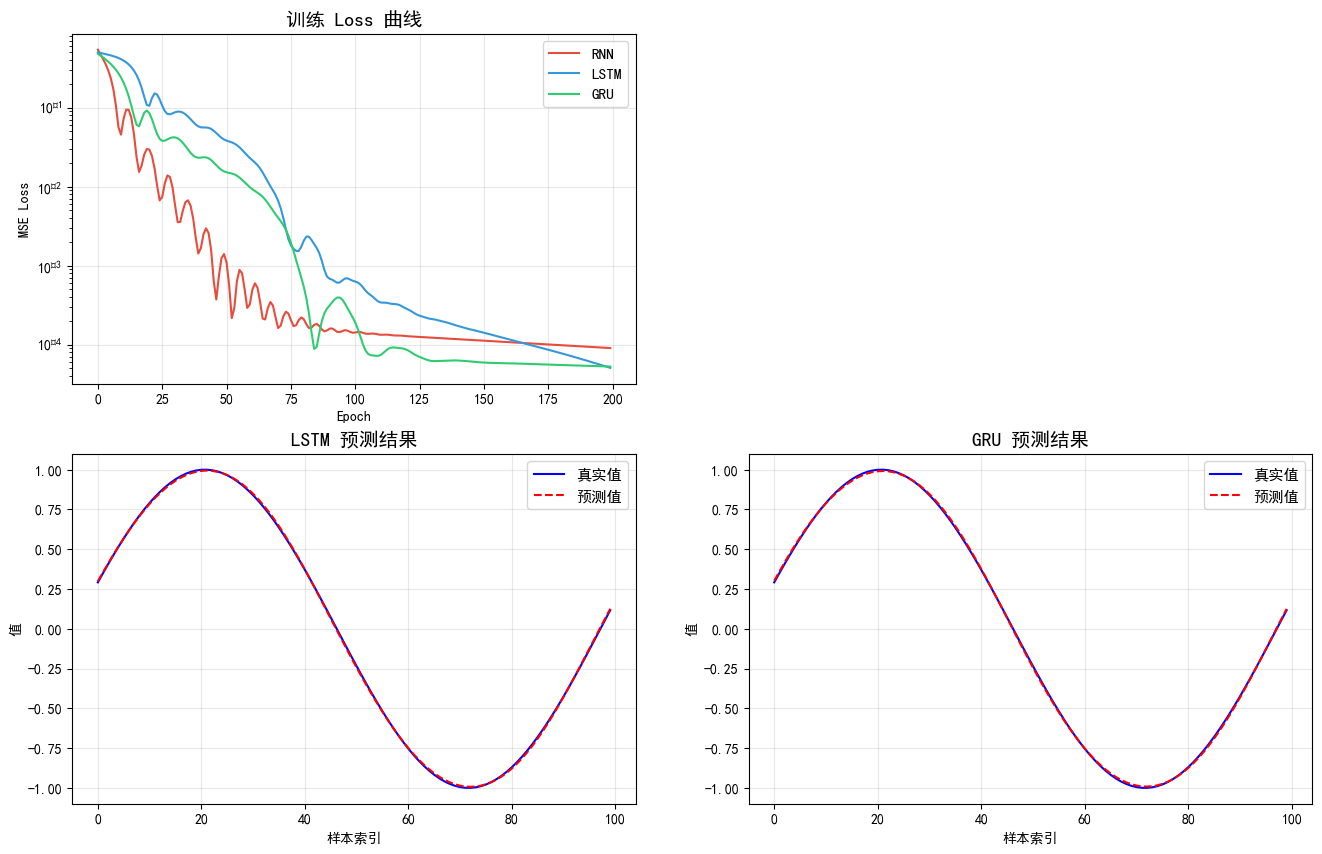

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


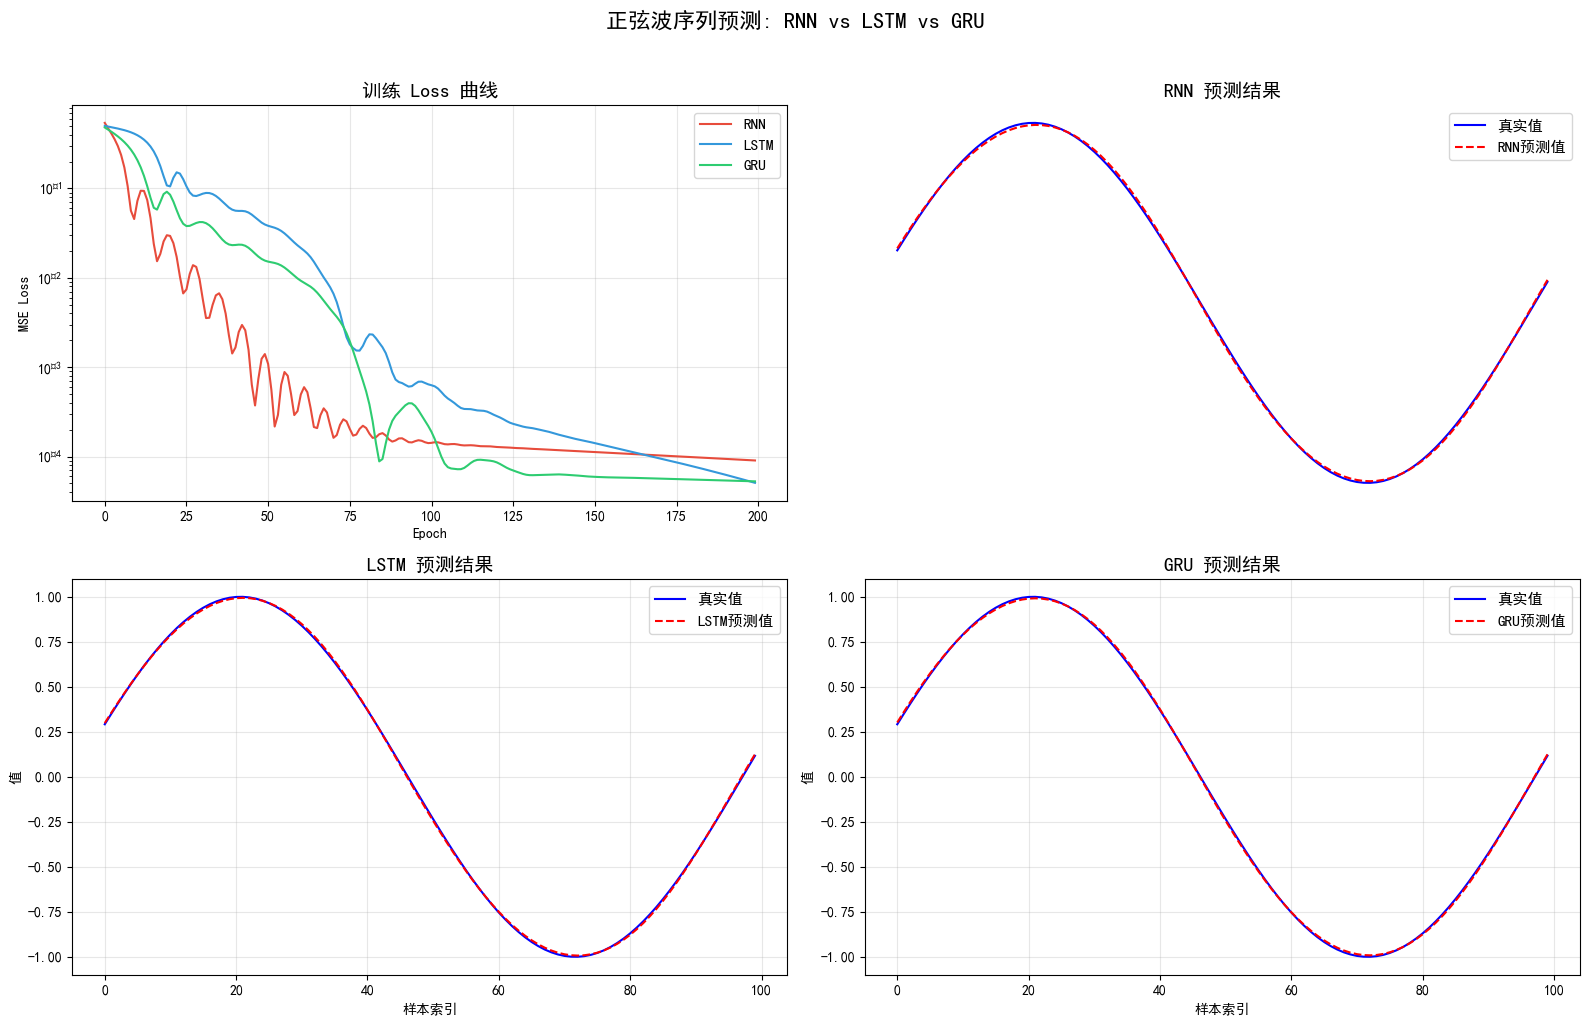

In [19]:
# ========== 4. 结果可视化 ==========

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 左上: 训练 loss 曲线
colors = {'RNN': '#e74c3c', 'LSTM': '#3498db', 'GRU': '#2ecc71'}
for name, res in results.items():
    axes[0, 0].plot(res['train_loss'], label=name, color=colors[name], linewidth=1.5)
axes[0, 0].set_title('训练 Loss 曲线', fontsize=14)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_yscale('log')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 右上、左下、右下: 各模型预测结果
for idx, (name, res) in enumerate(results.items()):
    ax = axes[(idx+1)//2, (idx+1)%2] if idx > 0 else axes[0, 1]
    ax = axes[0, 1] if idx == 0 else axes[1, idx-1]
    
    model = res['model']
    model.eval()
    with torch.no_grad():
        preds = model(res['X_test'])
    
    n_show = 100
    ax.plot(res['y_test'][:n_show].numpy(), 'b-', label='真实值', linewidth=1.5)
    ax.plot(preds[:n_show].numpy(), 'r--', label='预测值', linewidth=1.5)
    ax.set_title(f'{name} 预测结果', fontsize=14)
    ax.set_xlabel('样本索引')
    ax.set_ylabel('值')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

# 重新布局
plt.delaxes(axes[0, 1])
axes_flat = [axes[0, 0], axes[1, 0], axes[1, 1]]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Loss 曲线
for name, res in results.items():
    axes[0, 0].plot(res['train_loss'], label=name, color=colors[name], linewidth=1.5)
axes[0, 0].set_title('训练 Loss 曲线', fontsize=14)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_yscale('log')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 各模型预测
for idx, (name, res) in enumerate(results.items()):
    row = (idx + 1) // 2
    col = (idx + 1) % 2
    ax = axes[row, col]
    
    model = res['model']
    model.eval()
    with torch.no_grad():
        preds = model(res['X_test'])
    
    n_show = 100
    ax.plot(res['y_test'][:n_show].numpy(), 'b-', label='真实值', linewidth=1.5)
    ax.plot(preds[:n_show].numpy(), 'r--', label=f'{name}预测值', linewidth=1.5)
    ax.set_title(f'{name} 预测结果', fontsize=14)
    ax.set_xlabel('样本索引')
    ax.set_ylabel('值')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

# 隐藏多余的子图
axes[0, 1].axis('off')

plt.suptitle('正弦波序列预测: RNN vs LSTM vs GRU', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
# 第二部分：生成对抗网络 (GAN)

---
## 6. GAN 基本原理

### 6.1 什么是 GAN？

生成对抗网络（Generative Adversarial Network，GAN）由 Ian Goodfellow 于 2014 年提出。

GAN 由两个网络组成：

```
      噪声 z
        │
        ▼
  ┌──────────┐      生成数据 G(z)
  │ 生成器 G  │──────────────┐
  └──────────┘              │
                             ▼
                       ┌──────────┐
  真实数据 ─────────→ │ 判别器 D  │ → 真/假
                       └──────────┘
```

- **生成器 (Generator, G)**：从随机噪声 $z$ 生成"假"数据，目标是**骗过判别器**
- **判别器 (Discriminator, D)**：区分输入数据是真实的还是生成的，目标是**不被骗过**

### 6.2 Min-Max 博弈

GAN 的训练目标是一个**极小极大博弈**：

$$\min_G \max_D \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

**直觉理解：**

- **判别器 $D$ 的目标（最大化）**：
  - 对真实数据 $x$，输出 $D(x) \approx 1$（判为真）
  - 对生成数据 $G(z)$，输出 $D(G(z)) \approx 0$（判为假）

- **生成器 $G$ 的目标（最小化）**：
  - 让 $D(G(z)) \approx 1$（骗过判别器，让假数据被判为真）

理想均衡：$p_G = p_{data}$（生成分布 = 真实分布），此时 $D(x) = 0.5$（判别器无法区分）。

### 6.3 GAN 训练过程

```
for each training iteration:
    # 步骤1: 训练判别器
    1. 从真实数据中采样 x
    2. 从噪声先验中采样 z
    3. 用生成器生成假数据 G(z)
    4. D 的损失 = -[log D(x) + log(1 - D(G(z)))]
    5. 更新 D 的参数
    
    # 步骤2: 训练生成器
    1. 从噪声先验中采样 z
    2. 用生成器生成假数据 G(z)
    3. G 的损失 = -log D(G(z))  (希望 D(G(z)) → 1)
    4. 更新 G 的参数（D 的参数固定）
```

In [20]:
# ========== GAN 基本实现: 生成一维正态分布数据 ==========

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 真实数据分布: 两个高斯混合
def real_data_distribution(n_samples):
    """生成真实数据: 两个高斯分布的混合"""
    n1 = n_samples // 2
    n2 = n_samples - n1
    data1 = np.random.normal(-2, 0.5, n1)
    data2 = np.random.normal(2, 0.5, n2)
    return torch.FloatTensor(np.concatenate([data1, data2]))


# ========== 生成器 ==========
class Generator(nn.Module):
    def __init__(self, latent_dim=1, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    
    def forward(self, z):
        return self.net(z)


# ========== 判别器 ==========
class Discriminator(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()  # 输出概率 [0, 1]
        )
    
    def forward(self, x):
        return self.net(x)


# 创建模型
latent_dim = 1
G = Generator(latent_dim=latent_dim)
D = Discriminator()

print(f"生成器参数量: {sum(p.numel() for p in G.parameters()):,}")
print(f"判别器参数量: {sum(p.numel() for p in D.parameters()):,}")

生成器参数量: 1,153
判别器参数量: 1,153


In [21]:
# ========== 训练 GAN ==========

lr = 0.001
n_epochs = 2000
batch_size = 128

# 优化器
optimizer_G = torch.optim.Adam(G.parameters(), lr=lr)
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr)

# 损失函数
criterion = nn.BCELoss()  # Binary Cross Entropy

# 记录
d_losses = []
g_losses = []

for epoch in range(n_epochs):
    # 采样真实数据
    real_data = real_data_distribution(batch_size).unsqueeze(1)  # (128, 1)
    real_labels = torch.ones(batch_size, 1)    # 真实标签 = 1
    
    # 采样噪声
    z = torch.randn(batch_size, latent_dim)     # (128, 1)
    fake_data = G(z).detach()                   # 生成假数据（detach!）
    fake_labels = torch.zeros(batch_size, 1)    # 假标签 = 0
    
    # ---- 训练判别器 D ----
    optimizer_D.zero_grad()
    
    # D 对真实数据的损失 (希望 D(real)=1)
    d_real_loss = criterion(D(real_data), real_labels)
    # D 对假数据的损失 (希望 D(fake)=0)
    d_fake_loss = criterion(D(fake_data), fake_labels)
    d_loss = d_real_loss + d_fake_loss
    
    d_loss.backward()
    optimizer_D.step()
    
    # ---- 训练生成器 G ----
    optimizer_G.zero_grad()
    
    z = torch.randn(batch_size, latent_dim)
    fake_data = G(z)  # 注意: 不要 detach!
    
    # G 的损失 (希望 D(G(z))=1, 即假数据被判为真)
    g_loss = criterion(D(fake_data), real_labels)
    
    g_loss.backward()
    optimizer_G.step()
    
    d_losses.append(d_loss.item())
    g_losses.append(g_loss.item())
    
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1:4d}/{n_epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch  200/2000 | D Loss: 0.9369 | G Loss: 1.1824
Epoch  400/2000 | D Loss: 0.9082 | G Loss: 1.0236
Epoch  600/2000 | D Loss: 1.0074 | G Loss: 0.9099
Epoch  800/2000 | D Loss: 1.0570 | G Loss: 1.4563
Epoch 1000/2000 | D Loss: 0.9592 | G Loss: 1.0983
Epoch 1200/2000 | D Loss: 0.9669 | G Loss: 1.0449
Epoch 1400/2000 | D Loss: 0.9453 | G Loss: 1.5547
Epoch 1600/2000 | D Loss: 0.9991 | G Loss: 0.9352
Epoch 1800/2000 | D Loss: 1.2192 | G Loss: 1.5287
Epoch 2000/2000 | D Loss: 1.2143 | G Loss: 0.8511


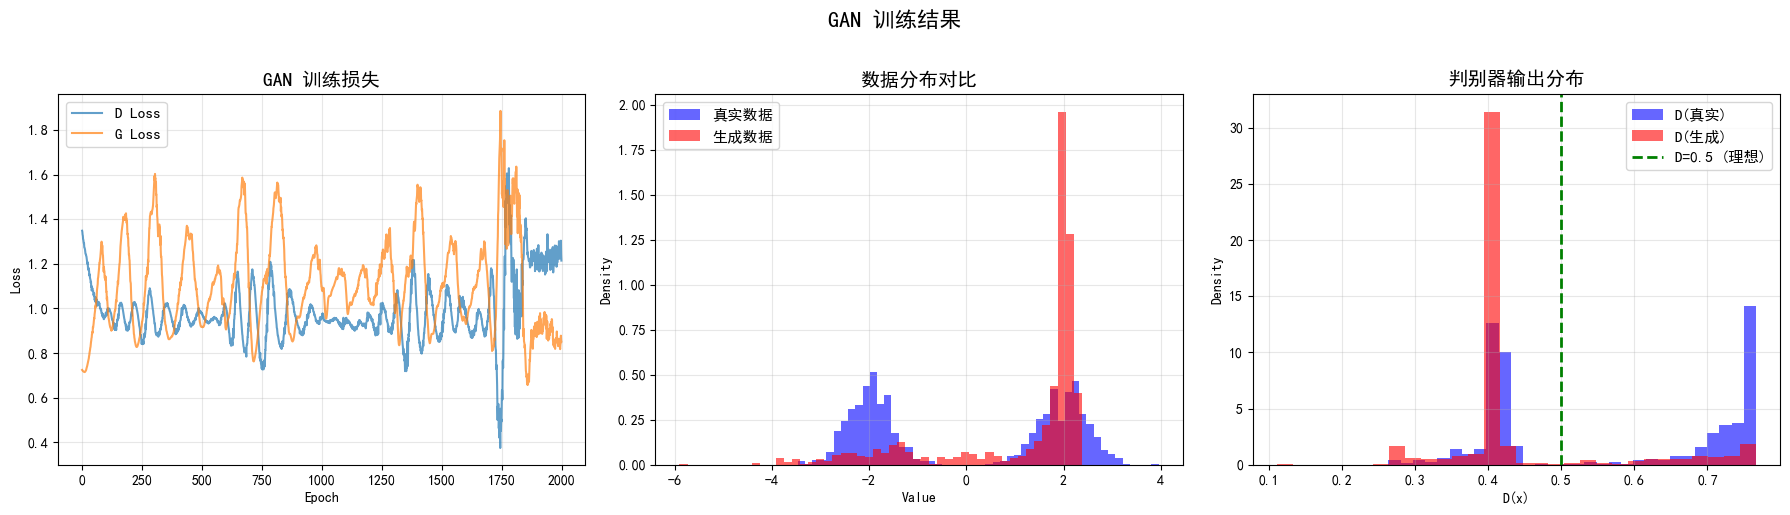

In [22]:
# ========== GAN 训练结果可视化 ==========

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 损失曲线
axes[0].plot(d_losses, alpha=0.7, label='D Loss')
axes[0].plot(g_losses, alpha=0.7, label='G Loss')
axes[0].set_title('GAN 训练损失', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. 真实数据 vs 生成数据分布
G.eval()
with torch.no_grad():
    z = torch.randn(1000, latent_dim)
    fake_samples = G(z).numpy().flatten()

real_samples = real_data_distribution(1000).numpy()

axes[1].hist(real_samples, bins=50, density=True, alpha=0.6, label='真实数据', color='blue')
axes[1].hist(fake_samples, bins=50, density=True, alpha=0.6, label='生成数据', color='red')
axes[1].set_title('数据分布对比', fontsize=14)
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# 3. 判别器输出分布
D.eval()
with torch.no_grad():
    real_scores = D(torch.FloatTensor(real_samples).unsqueeze(1)).numpy()
    fake_scores = D(torch.FloatTensor(fake_samples).unsqueeze(1)).numpy()

axes[2].hist(real_scores, bins=30, density=True, alpha=0.6, label='D(真实)', color='blue')
axes[2].hist(fake_scores, bins=30, density=True, alpha=0.6, label='D(生成)', color='red')
axes[2].axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='D=0.5 (理想)')
axes[2].set_title('判别器输出分布', fontsize=14)
axes[2].set_xlabel('D(x)')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.suptitle('GAN 训练结果', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 6.4 GAN 的常见问题

| 问题 | 描述 | 解决方案 |
|------|------|----------|
| **模式崩溃 (Mode Collapse)** | G 只生成少数几种样本 | WGAN、Minibatch Discrimination |
| **训练不稳定** | D 和 G 交替占优，震荡 | 调整学习率、WGAN-GP |
| **梯度消失** | G 的梯度无法传回 | 修改 G 的损失为 $-\log D(G(z))$ |

---
## 7. 常见 GAN 变体

| 变体 | 核心改进 | 年份 |
|------|----------|------|
| **原始 GAN** | Min-Max 博弈 | 2014 |
| **DCGAN** | 使用卷积/反卷积结构，图像生成质量大幅提升 | 2015 |
| **Conditional GAN (cGAN)** | 加入条件信息（标签、文本），可控生成 | 2014 |
| **WGAN** | 使用 Wasserstein 距离替代 JS 散度，训练更稳定 | 2017 |
| **WGAN-GP** | 使用梯度惩罚替代权重裁剪 | 2017 |
| **InfoGAN** | 解耦生成特征，无监督学习有意义的表示 | 2016 |
| **CycleGAN** | 无配对图像翻译（如：马↔斑马） | 2017 |
| **StyleGAN** | 基于样式的生成，控制不同层次的图像特征 | 2019 |
| **StyleGAN2/3** | 消除伪影，提升质量/效率 | 2020/2021 |

### DCGAN 架构（图像生成常用）

```python
# DCGAN 生成器 (反卷积上采样)
Generator = nn.Sequential(
    nn.ConvTranspose2d(100, 512, 4, 1, 0),   # (100,1,1) → (512,4,4)
    nn.BatchNorm2d(512), nn.ReLU(True),
    nn.ConvTranspose2d(512, 256, 4, 2, 1),   # → (256,8,8)
    nn.BatchNorm2d(256), nn.ReLU(True),
    nn.ConvTranspose2d(256, 128, 4, 2, 1),  # → (128,16,16)
    nn.BatchNorm2d(128), nn.ReLU(True),
    nn.ConvTranspose2d(128, 3, 4, 2, 1),     # → (3,32,32)
    nn.Tanh()                                 # 输出 [-1, 1]
)

# DCGAN 判别器 (卷积下采样)
Discriminator = nn.Sequential(
    nn.Conv2d(3, 128, 4, 2, 1), nn.LeakyReLU(0.2),
    nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
    nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2),
    nn.Conv2d(512, 1, 4, 1, 0), nn.Sigmoid()
)
```

---
## 8. 本节小结

### RNN 家族

| 模型 | 门控 | 状态 | 适用场景 |
|------|------|------|----------|
| Vanilla RNN | 无 | $h_t$ | 简单序列，短距离依赖 |
| LSTM | 3门 (遗忘/输入/输出) | $h_t, C_t$ | 长序列，复杂依赖 |
| GRU | 2门 (重置/更新) | $h_t$ | 中等序列，效率优先 |

**关键技巧：**
- 梯度裁剪：`torch.nn.utils.clip_grad_norm_()`
- 双向：`bidirectional=True` 捕获前后文信息
- 多层：`num_layers > 1` 增加模型容量

### GAN

| 概念 | 要点 |
|------|------|
| 核心思想 | 生成器与判别器的对抗训练 |
| 目标函数 | $\min_G \max_D \mathbb{E}[\log D(x)] + \mathbb{E}[\log(1-D(G(z)))]$ |
| 训练技巧 | 分别交替训练 D 和 G |
| 常见问题 | 模式崩溃、训练不稳定 |
| 代表变体 | DCGAN, WGAN, CycleGAN, StyleGAN |

---

## 📝 练习题

### 练习1: RNN 文本分类

使用 PyTorch 内置的 `nn.LSTM` 构建一个情感分析模型：
- 输入：一段文本（词嵌入后维度为 `(batch, seq_len, embed_dim)`）
- 使用双向 LSTM，hidden_size=128，2 层
- 取最后一个时间步的输出进行二分类（正面/负面）
- 使用随机数据模拟训练过程

**提示：** 双向 LSTM 的 `[0]` 和 `[1]` 分别是正向和反向的最终隐藏状态，可以用 `torch.cat([hn[0], hn[1]], dim=1)` 拼接。

### 练习2: 多步序列预测

修改正弦波预测实验，改为**多步预测**：给定前 20 个时间步，预测未来 5 个时间步。

**提示：**
- 修改模型输出维度为 5
- 修改损失函数和标签
- 可视化多步预测结果

### 练习3: GAN 改进

尝试以下改进并对比效果：
1. 将 GAN 的生成器和判别器都改为 3 层（增加深度）
2. 使用 LeakyReLU 替换 Sigmoid（判别器最后一层除外）
3. 在判别器中使用 Dropout
4. 调整学习率（尝试 0.0001 和 0.01）

观察哪种配置下生成数据的分布最接近真实数据。